In [1]:
import torch # torch will allow us to create tensors.
import torch.nn as nn # torch.nn allows us to create a neural network and allows
                      # us to access a lot of useful functions like:
                      # nn.Linear, nn.Embedding, nn.CrossEntropyLoss() etc.

from torch.optim import Adam # optim contains many optimizers. This time we're using Adam
from torch.distributions.uniform import Uniform # So we can initialize our tensors with a uniform distribution
from torch.utils.data import TensorDataset, DataLoader # these are needed for the training data

import lightning as L # lightning has tons of cool tools that make neural networks easier

import pandas as pd ## to create dataframes from graph input
import matplotlib.pyplot as plt ## matplotlib allows us to draw graphs.
import seaborn as sns ## seaborn makes it easier to draw nice-looking graphs.

In [2]:
## create the training data for the neural network.
inputs = torch.tensor([[1., 0., 0., 0.], # one-hot-encoding for Troll 2...
                       [0., 1., 0., 0.], # ...is
                       [0., 0., 1., 0.], # ...great
                       [0., 0., 0., 1.]]) # ...Gymkata

labels = torch.tensor([[0., 1., 0., 0.], # "Troll 2" is followed by "is"
                       [0., 0., 1., 0.], # "is" is followed by "great"
                       [0., 0., 0., 1.], # "great" isn't followed by anything, but we'll pretend it was followed by "Gymkata"
                       [0., 1., 0., 0.]]) # "Gymkata", just like "Troll 2", is followed by "is".

In [3]:
dataset = TensorDataset(inputs, labels) 
dataloader = DataLoader(dataset)

In [ ]:
class WordEmbeddingFromScratch(L.LightningModule):

    def __init__(self):
        ## __init__() initializes the weights and sets everything up for training
        
        super().__init__()
        
        ## The first thing we do is set the seed for the random number generorator.
        ## This ensures that when someone creates a model from this class, that model
        ## will start off with the exact same random numbers as I started out with when
        ## I created this demo. At least, I hope that is what happens!!! :)
        L.seed_everything(seed=42)
        
        ###################
        ##
        ## Initialize the weights.
        ##
        ## NOTE: We're initializing the weights using values from a uniform distribtion
        ##       that goes from -0.5 to 0.5 (this is notated as U(-0.5, 0.5). 
        ##       This is because of how nn.Linear() initializes weights -
        ##       nn.Linear() uses U(-sqrt(k), sqrt(k)), where k=1/in_features.
        ##       In our case, we have 4 inputs, so k=1/4 = 0.25. And the sqrt(0.25) = 0.5.
        ##       Thus, nn.Linear() would use U(-0.5, 0.5) to initialize the weights, so 
        ##       that's what we'll do here as well.
        ##
        ###################
        min_value = -0.5
        max_value = 0.5
        
        ## Now we initialize the weights that feed 4 inputs (one for each unique word) 
        ##       into the 2 nodes in the hidden layer (top and bottom nodes)
        ##
        ## NOTE: Because we want words (or tokens) that are used in the same context to have similar
        ##       weights, we are excluding bias terms from the connections from the inputs to the
        ##       nodes in the hidden layer (alternatively, you could think that
        ##       we set the bias terms to 0 and are not going to optimize them).
        ##
        ## ALSO NOTE: We're using nn.Parameter() here instead of torch.tensor() because we want
        ##       to easily print out the parameters before and after training. Parameters are just
        ##       tensors that are added to model's parameter list.
        self.input1_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input1_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.input2_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input2_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.input3_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input3_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.input4_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input4_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        ## Now we initialize the weights that come out of the hidden layer to the "output"
        ## NOTE: Again, we are excluding bias terms. This time, we exclude them simply because
        ##       we do not need them.
        self.output1_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output1_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.output2_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output2_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.output3_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output3_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.output4_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output4_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        ## For the loss function, we'll use CrossEntropyLoss, which we'll use in training_step()
        ## NOTE: The nn.CrossEntropyLoss automatically applies softmax for us, so we don't need to import it.
        self.loss = nn.CrossEntropyLoss()
        
        
    def forward(self, input): 
        ## forward() is where we do the math associated with running the inputs through the
        ## network
        
        ## The input is delivered inside of a list, like this...
        ##   [[1., 0., 0., 0.]]
        ## ...and it's just easier if we remove the extra pair of brackets so we only have...
        ##   [1., 0., 0., 0.]
        ## ...so let's do it.
        input = input[0]
        
        ## First, for the top node in the hidden layer, 
        ## we multiply each input by its weight, 
        ## and then calculate the sum of those products...
        inputs_to_top_hidden = ((input[0] * self.input1_w1) + 
                                (input[1] * self.input2_w1) + 
                                (input[2] * self.input3_w1) + 
                                (input[3] * self.input4_w1))
        
        ## ...then, for the bottom node in the hidden layer,
        ## we multiply each input by its weight, 
        ## and then calculate the sum of those products.
        inputs_to_bottom_hidden = ((input[0] * self.input1_w2) +
                                   (input[1] * self.input2_w2) +
                                   (input[2] * self.input3_w2) +
                                   (input[3] * self.input4_w2))
        
        ## Now, in theory, we could run inputs_to_top_hidden and inputs_to_bottom_hidden through 
        ## linear activation functions, but the outputs would be the exact same as in the inputs, 
        ## so we can just skip that step and instead compute the 4 output values from the 2 nodes in hidden layer
        ## by summing the products of the hidden layer values and a pair of weights for each output.
        output1 = ((inputs_to_top_hidden * self.output1_w1) + 
                   (inputs_to_bottom_hidden * self.output1_w2))
        output2 = ((inputs_to_top_hidden * self.output2_w1) + 
                   (inputs_to_bottom_hidden * self.output2_w2))
        output3 = ((inputs_to_top_hidden * self.output3_w1) + 
                   (inputs_to_bottom_hidden * self.output3_w2))
        output4 = ((inputs_to_top_hidden * self.output4_w1) + 
                   (inputs_to_bottom_hidden * self.output4_w2))
        
        ## Now we need to concatenate the 4 output tensors so that we can run them through 
        ## the SoftMax function. However, because they are tensors (and have gradients attached to them), 
        ## we can't just combine them in a simple list like this...
        # output_values = [output1, output2, output3, output4] ## THIS WILL NOT WORK
        ## ...because that would strip off the gradients. 
        ## Instead, we use torch.stack(), which retains the gradients.
        output_presoftmax = torch.stack([output1, output2, output3, output4])
        ## NOTE: The the loss function we are using, nn.CrossEntropyLoss, automatically applies softmax for us, so we
        ##       need to do that ourselves. If we want to actually use this network to predict the next word
        ##       (instead of just using it for the Word Embedding values), then we'll need to apply the softmax() function
        ##       ourselves (or just look to see what output value is largest).
        
        return(output_presoftmax)
        
        
    def configure_optimizers(self): 
        # configure_optimizers() configures the optimizer we want to use for backpropagation.
        
        return Adam(self.parameters(), lr=0.1) # lr=0.1 sets the learning rate to 0.1

    
    def training_step(self, batch, batch_idx): 
        # training_step() takes a step of gradient descent.

        input_i, label_i = batch # collect input
        output_i = self.forward(input_i) # run input through the neural network
        loss = self.loss(output_i, label_i[0]) ## loss = cross entropy
                    
        return loss

In [5]:
modelFromScratch = WordEmbeddingFromScratch() # create the model...

print("Before optimization, the parameters are...")
for name, param in modelFromScratch.named_parameters():
    print(name, torch.round(param.data, decimals=2))

Seed set to 42


Before optimization, the parameters are...
input1_w1 tensor(0.3800)
input1_w2 tensor(0.4200)
input2_w1 tensor(-0.1200)
input2_w2 tensor(0.4600)
input3_w1 tensor(-0.1100)
input3_w2 tensor(0.1000)
input4_w1 tensor(-0.2400)
input4_w2 tensor(0.2900)
output1_w1 tensor(0.4400)
output1_w2 tensor(-0.3700)
output2_w1 tensor(0.4300)
output2_w2 tensor(0.0900)
output3_w1 tensor(0.3700)
output3_w2 tensor(0.0700)
output4_w1 tensor(0.2400)
output4_w2 tensor(-0.0700)


In [6]:
data = {
    "w1": [modelFromScratch.input1_w1.item(), ## item() pulls out the tensor value as a float
           modelFromScratch.input2_w1.item(), 
           modelFromScratch.input3_w1.item(), 
           modelFromScratch.input4_w1.item()],
    "w2": [modelFromScratch.input1_w2.item(), 
           modelFromScratch.input2_w2.item(), 
           modelFromScratch.input3_w2.item(), 
           modelFromScratch.input4_w2.item()],
    "token": ["Troll2", "is", "great", "Gymkata"],
    "input": ["input1", "input2", "input3", "input4"]
}
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,0.382269,0.415004,Troll2,input1
1,-0.117136,0.459306,is,input2
2,-0.109552,0.100895,great,input3
3,-0.243428,0.293641,Gymkata,input4


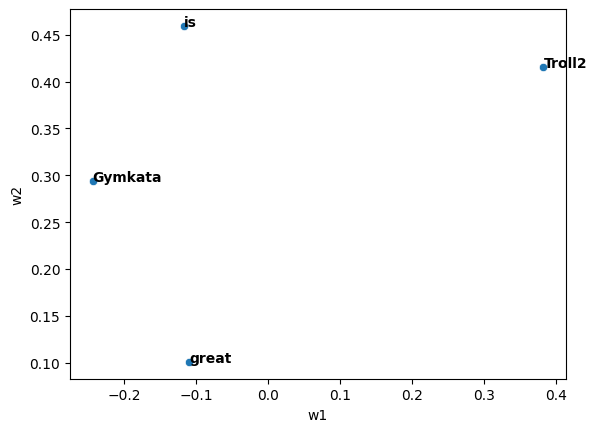

In [7]:
sns.scatterplot(data=df, x="w1", y="w2")

## add the token that each dot represents to the graph
# Troll 2
plt.text(df.w1[0], df.w2[0], df.token[0], 
         horizontalalignment='left', 
         size='medium', 
         color='black', 
         weight='semibold')

# is
plt.text(df.w1[1], df.w2[1], df.token[1], 
         horizontalalignment='left', 
         size='medium', 
         color='black', 
         weight='semibold') 

# great
plt.text(df.w1[2], df.w2[2], df.token[2], 
         horizontalalignment='left', 
         size='medium', 
         color='black', 
         weight='semibold')

# Gymkata
plt.text(df.w1[3], df.w2[3], df.token[3], 
         horizontalalignment='left', 
         size='medium', 
         color='black', 
         weight='semibold')

plt.show()

In [8]:
trainer = L.Trainer(max_epochs=100)
trainer.fit(modelFromScratch, train_dataloaders=dataloader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\Bryan Ngu\Desktop\UM_Intern\env\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name         | Type             | Params | Mode 
----------------------------------------------------------
0 | loss         | CrossEntr

Epoch 99: 100%|██████████| 4/4 [00:00<00:00, 105.70it/s, v_num=5]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 4/4 [00:00<00:00, 76.31it/s, v_num=5] 


In [9]:
print("After optimization, the parameters are...")
for name, param in modelFromScratch.named_parameters():
    print(name, torch.round(param.data, decimals=2))

After optimization, the parameters are...
input1_w1 tensor(2.0200)
input1_w2 tensor(1.9400)
input2_w1 tensor(-2.1800)
input2_w2 tensor(2.3200)
input3_w1 tensor(-2.0300)
input3_w2 tensor(-2.1600)
input4_w1 tensor(1.6900)
input4_w2 tensor(1.8900)
output1_w1 tensor(1.2600)
output1_w2 tensor(-1.7700)
output2_w1 tensor(3.0800)
output2_w2 tensor(1.3600)
output3_w1 tensor(-1.5800)
output3_w2 tensor(0.8800)
output4_w1 tensor(-1.5700)
output4_w2 tensor(-3.2900)


In [10]:
data = {
    "w1": [modelFromScratch.input1_w1.item(), ## item() pulls out the tensor value as a float
           modelFromScratch.input2_w1.item(), 
           modelFromScratch.input3_w1.item(), 
           modelFromScratch.input4_w1.item()],
    "w2": [modelFromScratch.input1_w2.item(), 
           modelFromScratch.input2_w2.item(), 
           modelFromScratch.input3_w2.item(), 
           modelFromScratch.input4_w2.item()],
    "token": ["Troll2", "is", "great", "Gymkata"],
    "input": ["input1", "input2", "input3", "input4"]
}
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,2.015867,1.941373,Troll2,input1
1,-2.181995,2.318636,is,input2
2,-2.028367,-2.161824,great,input3
3,1.691295,1.894237,Gymkata,input4


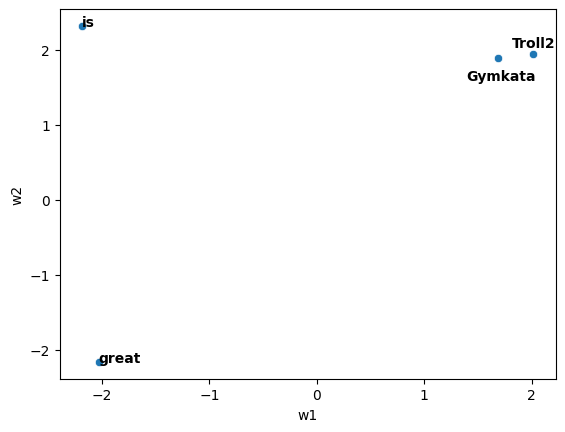

In [11]:
sns.scatterplot(data=df, x="w1", y="w2")

## NOTE: For Troll2 and and Gymkata, we're adding offsets to where to print the tokens because otherwise
## they will be so close to each other that they will overlap and be unreadable.

## Troll 2
plt.text(df.w1[0]-0.2, df.w2[0]+0.1, df.token[0], 
         horizontalalignment='left', 
         size='medium', 
         color='black', 
         weight='semibold')

## is
plt.text(df.w1[1], df.w2[1], df.token[1], 
         horizontalalignment='left', 
         size='medium', 
         color='black', 
         weight='semibold')

## great
plt.text(df.w1[2], df.w2[2], df.token[2],
         horizontalalignment='left', 
         size='medium', 
         color='black', 
         weight='semibold')

## gymkata
plt.text(df.w1[3]-0.3, df.w2[3]-0.3, df.token[3], 
         horizontalalignment='left', 
         size='medium', 
         color='black', 
         weight='semibold')

plt.show()

In [12]:
## Let's see what the model predicts

## First, let's create a softmax object...
softmax = nn.Softmax(dim=0) ## dim=0 applies softmax to rows, dim=1 applies softmax to columns

## Now let's...

## print the predictions for "Troll2"
print(torch.round(softmax(modelFromScratch(torch.tensor([[1., 0., 0., 0.]]))), 
                  decimals=2)) 

## print the predictions for "is"
print(torch.round(softmax(modelFromScratch(torch.tensor([[0., 1., 0., 0.]]))), 
                  decimals=2)) 

## print the predictions for "great"
print(torch.round(softmax(modelFromScratch(torch.tensor([[0., 0., 1., 0.]]))), 
                  decimals=2)) 

## print the predictions for "Gymkata"
print(torch.round(softmax(modelFromScratch(torch.tensor([[0., 0., 0., 1.]]))), 
                  decimals=2)) 

tensor([0., 1., 0., 0.], grad_fn=<RoundBackward1>)
tensor([0., 0., 1., 0.], grad_fn=<RoundBackward1>)
tensor([0., 0., 0., 1.], grad_fn=<RoundBackward1>)
tensor([0., 1., 0., 0.], grad_fn=<RoundBackward1>)
